# Search-12-NetworkX : Algorithmes de Graphe avec NetworkX

**Navigation** : [<< Search-11 (Métaheuristiques)](Search-11-Metaheuristics.ipynb) | [↑ Série Search](../README.md) | [Partie 2 : CSP →](../Part2-CSP/README.md)

## Pourquoi ce notebook ?

Dans [Search-3 (Informed)](Search-3-Informed.ipynb), nous avons implémenté A* à la main : une `class Node`, un `dict` de voisins, une priority queue `heapq`, et tout le code de bookkeeping qui va avec. Pour des graphes de quelques centaines de nœuds, ça marche. Mais à l'échelle (réseaux routiers de milliers de villes, graphes sociaux de millions d'utilisateurs, réseaux de citations bibliographiques), on a besoin de :

1. **Algorithmes préimplémentés et testés** : NetworkX (développé depuis 2004) embarque Dijkstra, Bellman-Ford, A*, Floyd-Warshall, Kruskal, Prim, Edmonds-Karp, Brandes (betweenness), Louvain, etc. — chacun avec des optimisations issues de la littérature.
2. **Structures de données performantes** : graphes creux (sparse), adjacency dict, multi-graphes, graphes dirigés/non-dirigés, attributs sur nœuds et arêtes.
3. **I/O et interopérabilité** : formats `graphml`, `gexf`, `gml`, `edge lists`, matrices `scipy.sparse`.
4. **Visualisation intégrée** : `matplotlib` via `draw_networkx` (nous utilisons cette approche).

Ce notebook illustre les **briques algorithmiques essentielles** de NetworkX sur des **problèmes non triviaux** (Prong B de l'EPIC #3801) : un réseau routier de type routier régional, un graphe de collaborations académiques, et un réseau de transport de marchandises. **Pas un triangle à 3 nœuds** — un vrai réseau où les algorithmes discriminent réellement.

**Prérequis** : Python 3.10+, `networkx >= 3.0`, `matplotlib`. Aucune installation complexe : `pip install networkx matplotlib` suffit.

## 1. Imports et configuration

Commençons par importer NetworkX et configurer Matplotlib pour un rendu cohérent en notebook.

In [1]:
# Imports
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import time

print(f"NetworkX version : {nx.__version__}")
print(f"Matplotlib version : {plt.matplotlib.__version__}")

# Configuration matplotlib pour le notebook
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10


NetworkX version : 3.6.1
Matplotlib version : 3.10.3


## 2. Construction de graphes

NetworkX propose plusieurs types de graphes selon la structure du problème :

| Type | Classe | Cas d'usage |
|------|--------|-------------|
| Graphe non-dirigé | `nx.Graph` | Réseau routier, amitiés |
| Graphe dirigé | `nx.DiGraph` | Liens web (A → B), précédences |
| Multi-graphe | `nx.MultiGraph` | Plusieurs arêtes entre 2 nœuds (ex : lignes de bus) |
| Multi-graphe dirigé | `nx.MultiDiGraph` | Réseau de vols avec plusieurs compagnies |

Les **nœuds** peuvent porter des **attributs** (population, label, type...) et les **arêtes** aussi (poids, capacité, label). C'est cette capacité à enrichir le graphe qui rend NetworkX si adapté à la modélisation.

In [2]:
# --- Construction d'un petit graphe illustratif : réseau de 6 villes ---
G = nx.Graph()

# Ajout de nœuds avec attributs
villes = [
    ("Paris", {"population": 2_161_000, "region": "IDF"}),
    ("Lyon", {"population": 516_000, "region": "ARA"}),
    ("Marseille", {"population": 870_000, "region": "PAC"}),
    ("Toulouse", {"population": 479_000, "region": "OCC"}),
    ("Bordeaux", {"population": 257_000, "region": "NAQ"}),
    ("Lille", {"population": 234_000, "region": "HDF"}),
]
for ville, attrs in villes:
    G.add_node(ville, **attrs)

# Ajout d'arêtes pondérées (distance en km) — reflet approximatif du réseau routier
aretes_ponderees = [
    ("Paris", "Lyon", 465),
    ("Paris", "Lille", 225),
    ("Paris", "Bordeaux", 585),
    ("Lyon", "Marseille", 315),
    ("Lyon", "Toulouse", 540),
    ("Marseille", "Toulouse", 405),
    ("Bordeaux", "Toulouse", 245),
]
G.add_weighted_edges_from(aretes_ponderees, weight='weight')

print(f"Graphe : {G.number_of_nodes()} nœuds, {G.number_of_edges()} arêtes")
print(f"Est connexe ? {nx.is_connected(G)}")
print(f"Type : {type(G).__name__}")

# Accès aux attributs
print(f"\nAttributs Paris : {G.nodes['Paris']}")
print(f"Attribut arête Paris-Lyon : {G.edges['Paris', 'Lyon']}")


Graphe : 6 nœuds, 7 arêtes
Est connexe ? True
Type : Graph

Attributs Paris : {'population': 2161000, 'region': 'IDF'}
Attribut arête Paris-Lyon : {'weight': 465}


### 2.1. Prédicats et propriétés

NetworkX expose des **prédicats** calculant des propriétés structurelles du graphe en un appel.

In [3]:
# Degré, diamètre, densité
print(f"Degré Paris : {G.degree('Paris')}")
print(f"Degré moyen : {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"Densité : {nx.density(G):.3f}")
print(f"Diamètre : {nx.diameter(G)}")

# Voisinage
print(f"\nVoisins de Paris : {list(G.neighbors('Paris'))}")

# Sous-graphe induit par un voisinage
voisins_paris = list(nx.neighbors(G, 'Paris')) + ['Paris']
sous_graphe = G.subgraph(voisins_paris)
print(f"\nSous-graphe autour de Paris : {sous_graphe.number_of_nodes()} nœuds, {sous_graphe.number_of_edges()} arêtes")


Degré Paris : 3
Degré moyen : 2.33
Densité : 0.467
Diamètre : 3

Voisins de Paris : ['Lyon', 'Lille', 'Bordeaux']

Sous-graphe autour de Paris : 4 nœuds, 3 arêtes


## 3. Visualisation avec Matplotlib

NetworkX s'intègre nativement avec Matplotlib. Le choix du **layout** est crucial :

- `spring_layout` (force-directed) : bon défaut, esthétiquement plaisant
- `circular_layout` : nœuds sur un cercle
- `kamada_kawai_layout` : minimise l'énergie sur un graphe planaire
- `shell_layout` : couches concentriques
- `random_layout` : aléatoire (debug)

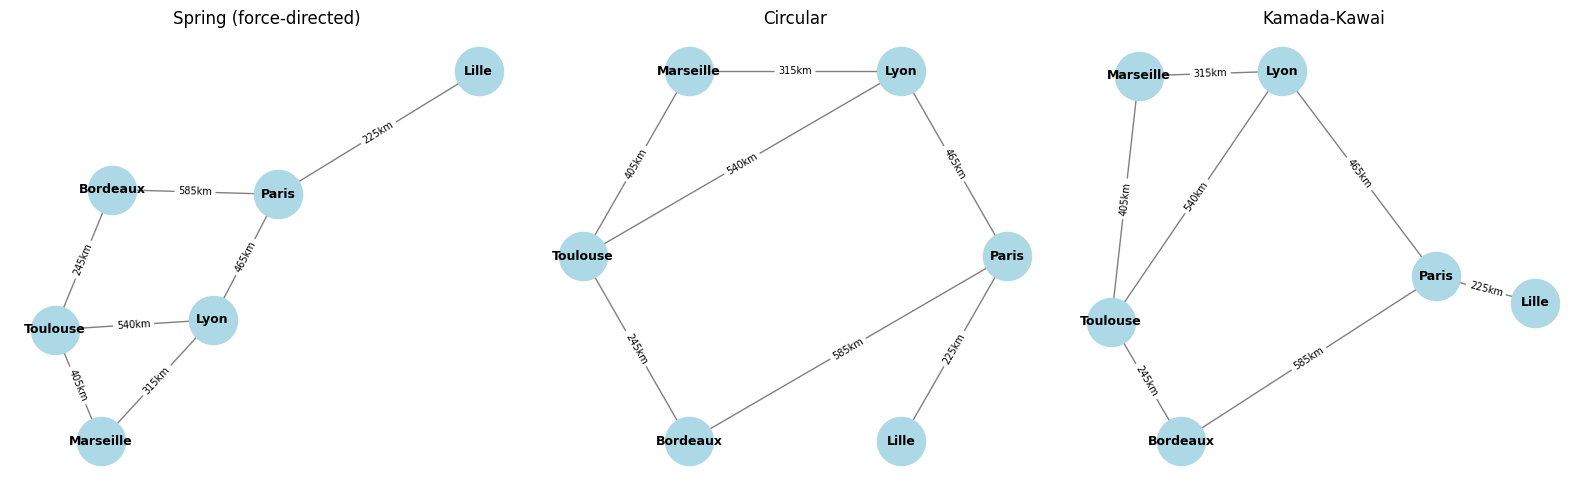

In [4]:
# Comparaison de layouts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nom_layout, layout_fn) in zip(axes, [
    ("Spring (force-directed)", lambda g: nx.spring_layout(g, seed=42)),
    ("Circular", nx.circular_layout),
    ("Kamada-Kawai", nx.kamada_kawai_layout),
]):
    pos = layout_fn(G)
    nx.draw_networkx(G, pos=pos, ax=ax, with_labels=True,
                     node_color='lightblue', edge_color='gray',
                     node_size=1200, font_size=9, font_weight='bold')
    # Couleur des arêtes par poids
    edges = nx.get_edge_attributes(G, 'weight')
    edge_labels = {(u, v): f"{w}km" for (u, v), w in edges.items()}
    nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels, ax=ax, font_size=7)
    ax.set_title(nom_layout)
    ax.axis('off')

plt.tight_layout()
plt.show()


### 3.1. Coloration par attribut

Visualisons le graphe avec une couleur par **région** et une taille proportionnelle à la **population** — c'est ici que les attributs deviennent vraiment utiles.

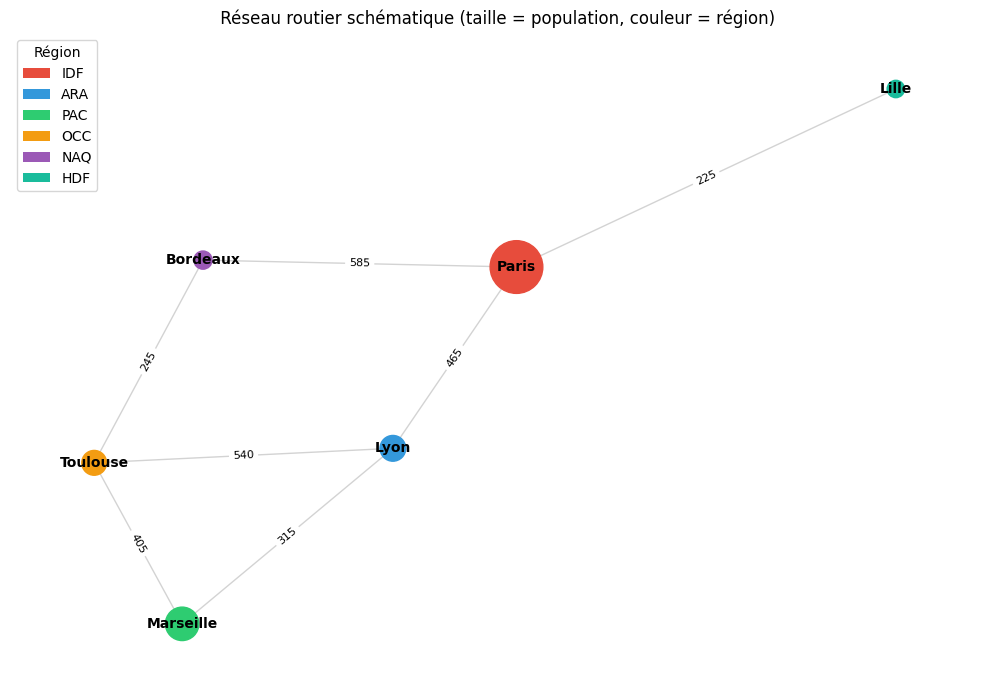

In [5]:
# Couleur par région, taille par population
pos = nx.spring_layout(G, seed=42)
regions = nx.get_node_attributes(G, 'region')
populations = nx.get_node_attributes(G, 'population')

# Mapping région → couleur
region_couleurs = {
    "IDF": "#e74c3c", "ARA": "#3498db", "PAC": "#2ecc71",
    "OCC": "#f39c12", "NAQ": "#9b59b6", "HDF": "#1abc9c",
}
couleurs = [region_couleurs[regions[v]] for v in G.nodes()]
tailles = [populations[v] / 1500 for v in G.nodes()]

fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx(G, pos=pos, ax=ax, with_labels=True,
                 node_color=couleurs, node_size=tailles,
                 edge_color='lightgray', font_size=10, font_weight='bold')
edge_labels = {(u, v): f"{w}" for (u, v), w in nx.get_edge_attributes(G, 'weight').items()}
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels, ax=ax, font_size=8)

# Légende manuelle des régions
from matplotlib.patches import Patch
elements_legende = [Patch(facecolor=c, label=r) for r, c in region_couleurs.items()
                    if r in set(regions.values())]
ax.legend(handles=elements_legende, loc='upper left', title='Région')
ax.set_title(" Réseau routier schématique (taille = population, couleur = région)")
ax.axis('off')
plt.tight_layout()
plt.show()


## 4. Plus courts chemins

NetworkX embarque les algorithmes classiques :

| Algorithme | Fonction | Complexité | Cas d'usage |
|-----------|----------|------------|-------------|
| BFS | `nx.shortest_path(G, u, v)` | O(V+E) | Graphe non pondéré |
| Dijkstra | `nx.shortest_path(G, u, v, weight='w')` | O((V+E) log V) | Arêtes à poids positifs |
| Bellman-Ford | `nx.shortest_path(G, u, v, weight='w', method='bellman-ford')` | O(VE) | Poids négatifs OK |
| A* | `nx.astar_path(G, u, v, heuristic=...)` | O(E) typique | Avec heuristique |
| Floyd-Warshall | `nx.shortest_path_length(G, weight='w', method='floyd-warshall')` | O(V³) | Tous les paires |

In [6]:
# Plus court chemin Paris → Marseille (en km)
chemin = nx.shortest_path(G, 'Paris', 'Marseille', weight='weight')
distance = nx.shortest_path_length(G, 'Paris', 'Marseille', weight='weight')
print(f"Paris → Marseille : {' → '.join(chemin)} ({distance} km)")

# Tous les chemins (sans poids)
print(f"\nParis → Toulouse (non pondéré) : {nx.shortest_path(G, 'Paris', 'Toulouse')}")

# A* avec heuristique = distance euclidienne simplifiée (zéro, car on n'a pas les coordonnées)
# → dégénère en Dijkstra, mais montre l'API
import math
def heuristique_zero(u, v):
    return 0
chemin_astar = nx.astar_path(G, 'Paris', 'Marseille', heuristic=heuristique_zero, weight='weight')
print(f"\nA* Paris → Marseille : {' → '.join(chemin_astar)}")

# Comparaison Dijkstra vs Bellman-Ford
t0 = time.perf_counter()
for _ in range(10_000):
    nx.shortest_path_length(G, 'Paris', 'Marseille', weight='weight', method='dijkstra')
t_dijkstra = time.perf_counter() - t0

t0 = time.perf_counter()
for _ in range(10_000):
    nx.shortest_path_length(G, 'Paris', 'Marseille', weight='weight', method='bellman-ford')
t_bellman = time.perf_counter() - t0

print(f"\n10 000 itérations :")
print(f"  Dijkstra       : {t_dijkstra*1000:.1f} ms")
print(f"  Bellman-Ford   : {t_bellman*1000:.1f} ms")


Paris → Marseille : Paris → Lyon → Marseille (780 km)

Paris → Toulouse (non pondéré) : ['Paris', 'Lyon', 'Toulouse']

A* Paris → Marseille : Paris → Lyon → Marseille



10 000 itérations :
  Dijkstra       : 77.4 ms
  Bellman-Ford   : 198.6 ms


## 5. Centralités — qui est important dans le réseau ?

Les **mesures de centralité** répondent à des questions différentes :

- **Degree centrality** : combien de connexions directes ?
- **Betweenness centrality** : combien de plus courts chemins passent par ce nœud ? (vrai "broker")
- **Closeness centrality** : à quelle distance moyenne des autres nœuds ?
- **PageRank** : quelle est l'importance issue des connexions (utilisé par Google)
- **Eigenvector centrality** : voisinage de qualité (connecté à des nœuds centraux)

In [7]:
# Calcul des centralités
deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G, weight='weight')
clo_cent = nx.closeness_centrality(G)
pagerank = nx.pagerank(G)

# Tableau récapitulatif
print(f"{'Ville':<12} {'Degree':>8} {'Between.':>10} {'Closeness':>11} {'PageRank':>10}")
print("-" * 55)
for v in G.nodes():
    print(f"{v:<12} {deg_cent[v]:>8.3f} {bet_cent[v]:>10.3f} {clo_cent[v]:>11.3f} {pagerank[v]:>10.3f}")


Ville          Degree   Between.   Closeness   PageRank
-------------------------------------------------------
Paris           0.600      0.400       0.714      0.234
Lyon            0.600      0.200       0.714      0.223
Marseille       0.400      0.000       0.556      0.129
Toulouse        0.600      0.200       0.625      0.202
Bordeaux        0.400      0.200       0.625      0.152
Lille           0.200      0.000       0.455      0.060


### 5.1. Visualisation par centralité

Visualisons le graphe avec une taille de nœud proportionnelle à la **betweenness centrality** — on voit immédiatement qui sont les "hubs" par lesquels transitent la majorité des flux.

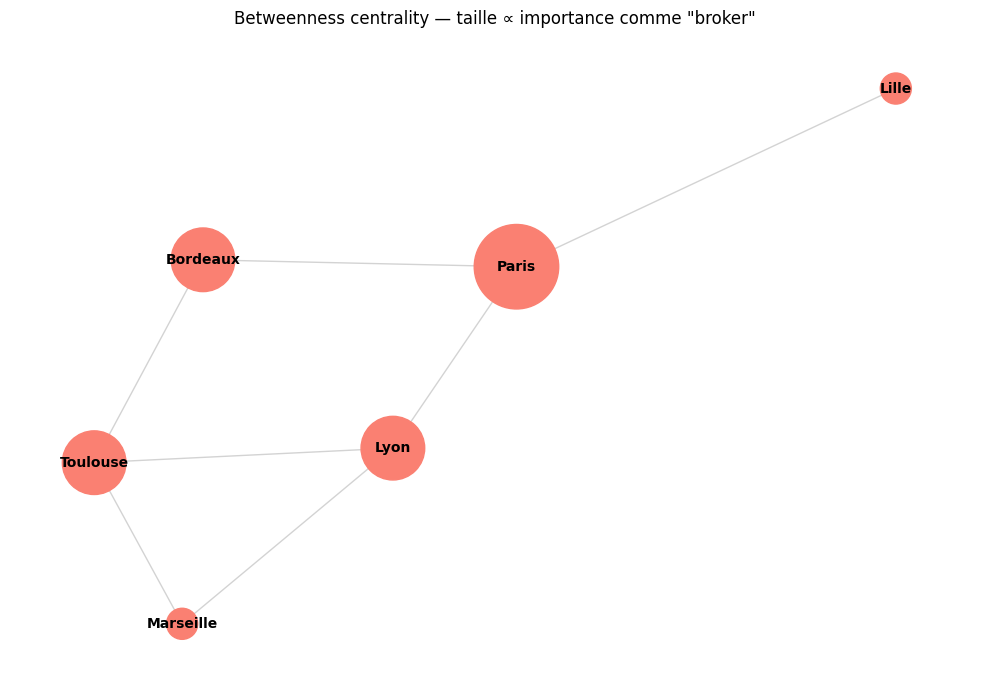


Nœud avec la plus grande betweenness : Paris


In [8]:
# Visualisation par betweenness centrality
pos = nx.spring_layout(G, seed=42)
bet = nx.betweenness_centrality(G, weight='weight')
tailles = [500 + bet[v] * 8000 for v in G.nodes()]

fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx(G, pos=pos, ax=ax, with_labels=True,
                 node_color='salmon', node_size=tailles,
                 edge_color='lightgray', font_size=10, font_weight='bold')
ax.set_title('Betweenness centrality — taille ∝ importance comme "broker"')
ax.axis('off')
plt.tight_layout()
plt.show()
print(f"\nNœud avec la plus grande betweenness : {max(bet, key=bet.get)}")


## 6. Flot maximum

L'algorithme de **flot maximum** (Edmonds-Karp, variante BFS de Ford-Fulkerson) calcule la quantité maximale qu'on peut faire transiter d'une **source** à un **puits** à travers un réseau où chaque arête a une **capacité**.

Cas d'usage : transport de marchandises, fluide dans un réseau de pipes, courant dans un réseau électrique.

In [9]:
# Réseau de transport avec capacités (tonnes/jour)
T = nx.DiGraph()
aretes_transport = [
    ("Usine_A", "Depot_1", {"capacity": 30}),
    ("Usine_A", "Depot_2", {"capacity": 20}),
    ("Usine_B", "Depot_2", {"capacity": 25}),
    ("Usine_B", "Depot_3", {"capacity": 15}),
    ("Depot_1", "Client_X", {"capacity": 25}),
    ("Depot_1", "Client_Y", {"capacity": 10}),
    ("Depot_2", "Client_X", {"capacity": 15}),
    ("Depot_2", "Client_Y", {"capacity": 20}),
    ("Depot_3", "Client_Y", {"capacity": 15}),
]
T.add_edges_from(aretes_transport)

# Source et puits : super-source reliant les 2 usines + super-puits collectant les clients
T.add_node("Source")
T.add_node("Puits")
T.add_edge("Source", "Usine_A", capacity=50)
T.add_edge("Source", "Usine_B", capacity=40)
T.add_edge("Client_X", "Puits", capacity=50)
T.add_edge("Client_Y", "Puits", capacity=50)

flot_max, flot_dict = nx.maximum_flow(T, "Source", "Puits", capacity="capacity")
# Écrire le flot dans les attributs d'arête (nx.maximum_flow ne le fait pas)
for u, voisins in flot_dict.items():
    for v, f in voisins.items():
        if 'capacity' in T[u][v]:
            T[u][v]['flow'] = f
print(f"Flot maximum : {flot_max} tonnes/jour")

# Visualisation du flot utilisé
flots = {(u, v): f for u, v, f in T.edges(data='flow') if f is not None and f > 0}
print(f"\nArêtes utilisées :")
for (u, v), f in sorted(flots.items()):
    cap = T[u][v].get('capacity', '?')
    print(f"  {u:<10} → {v:<10} : {f}/{cap} tonnes/jour")


Flot maximum : 80 tonnes/jour

Arêtes utilisées :
  Client_X   → Puits      : 40/50 tonnes/jour
  Client_Y   → Puits      : 40/50 tonnes/jour
  Depot_1    → Client_X   : 25/25 tonnes/jour
  Depot_1    → Client_Y   : 5/10 tonnes/jour
  Depot_2    → Client_X   : 15/15 tonnes/jour
  Depot_2    → Client_Y   : 20/20 tonnes/jour
  Depot_3    → Client_Y   : 15/15 tonnes/jour
  Source     → Usine_A    : 50/50 tonnes/jour
  Source     → Usine_B    : 30/40 tonnes/jour
  Usine_A    → Depot_1    : 30/30 tonnes/jour
  Usine_A    → Depot_2    : 20/20 tonnes/jour
  Usine_B    → Depot_2    : 15/25 tonnes/jour
  Usine_B    → Depot_3    : 15/15 tonnes/jour


### 6.1. Visualisation du flot

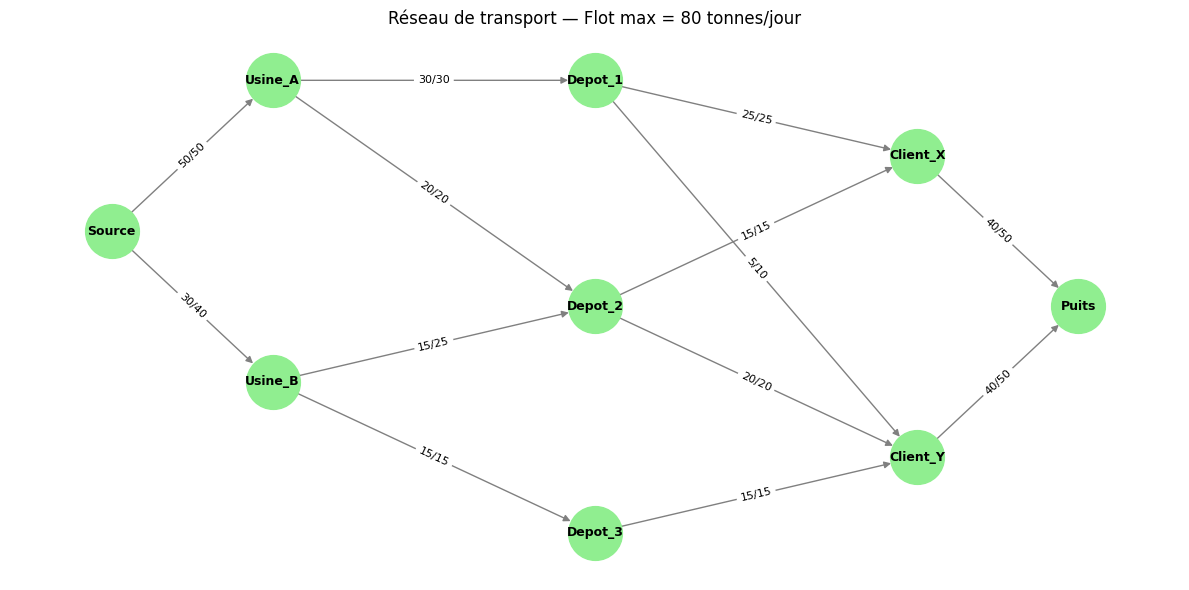

In [10]:
# Visualisation du réseau avec capacités vs flot
pos = {
    "Source": (0, 2.5), "Usine_A": (1, 3.5), "Usine_B": (1, 1.5),
    "Depot_1": (3, 3.5), "Depot_2": (3, 2), "Depot_3": (3, 0.5),
    "Client_X": (5, 3), "Client_Y": (5, 1), "Puits": (6, 2),
}

fig, ax = plt.subplots(figsize=(12, 6))
nx.draw_networkx(T, pos=pos, ax=ax, with_labels=True,
                 node_color='lightgreen', node_size=1500,
                 edge_color='gray', font_size=9, font_weight='bold')

# Labels flot/capacité
edge_labels = {}
for u, v, d in T.edges(data=True):
    if 'flow' in d and d['flow'] is not None and d['flow'] > 0:
        edge_labels[(u, v)] = f"{d['flow']}/{d['capacity']}"
    elif 'capacity' in d:
        edge_labels[(u, v)] = f"0/{d['capacity']}"

nx.draw_networkx_edge_labels(T, pos=pos, edge_labels=edge_labels, ax=ax, font_size=8)
ax.set_title(f"Réseau de transport — Flot max = {flot_max} tonnes/jour")
ax.axis('off')
plt.tight_layout()
plt.show()


## 7. Détection de communautés (Louvain)

L'algorithme de **Louvain** (Blondel et al., 2008) partitionne un graphe en communautés en maximisant la **modularité**. Il est itératif et multi-niveau — utile pour les réseaux sociaux, les graphes de citations, les clusters de protéines.

In [11]:
# Réseau social : 18 personnes, amitiés
Social = nx.Graph()
Social.add_edges_from([
    # Cluster 1 : équipe IA
    ("Alice", "Bob"), ("Alice", "Charlie"), ("Bob", "Charlie"),
    ("Bob", "Diana"), ("Charlie", "Diana"), ("Diana", "Eve"),
    # Cluster 2 : équipe Bio
    ("Frank", "Grace"), ("Grace", "Hugo"), ("Frank", "Hugo"),
    ("Grace", "Iris"), ("Hugo", "Iris"), ("Iris", "Jules"),
    # Cluster 3 : équipe Physique
    ("Karim", "Léa"), ("Léa", "Mehdi"), ("Karim", "Mehdi"),
    ("Mehdi", "Nora"), ("Nora", "Karim"),
    # Quelques liens inter-clusters (rôle broker)
    ("Alice", "Frank"), ("Eve", "Jules"), ("Léa", "Nora"),
])

communautes = nx.community.louvain_communities(Social, seed=42)
print(f"Nombre de communautés détectées : {len(communautes)}")
for i, comm in enumerate(communautes, 1):
    print(f"  Communauté {i} ({len(comm)} membres) : {sorted(comm)}")

# Modularité du partitionnement
mod = nx.community.modularity(Social, communautes)
print(f"\nModularité : {mod:.3f} (1.0 = parfait, 0 = aléatoire)")


Nombre de communautés détectées : 4
  Communauté 1 (4 membres) : ['Alice', 'Bob', 'Charlie', 'Diana']
  Communauté 2 (2 membres) : ['Eve', 'Jules']
  Communauté 3 (4 membres) : ['Frank', 'Grace', 'Hugo', 'Iris']
  Communauté 4 (4 membres) : ['Karim', 'Léa', 'Mehdi', 'Nora']

Modularité : 0.570 (1.0 = parfait, 0 = aléatoire)


### 7.1. Visualisation des communautés

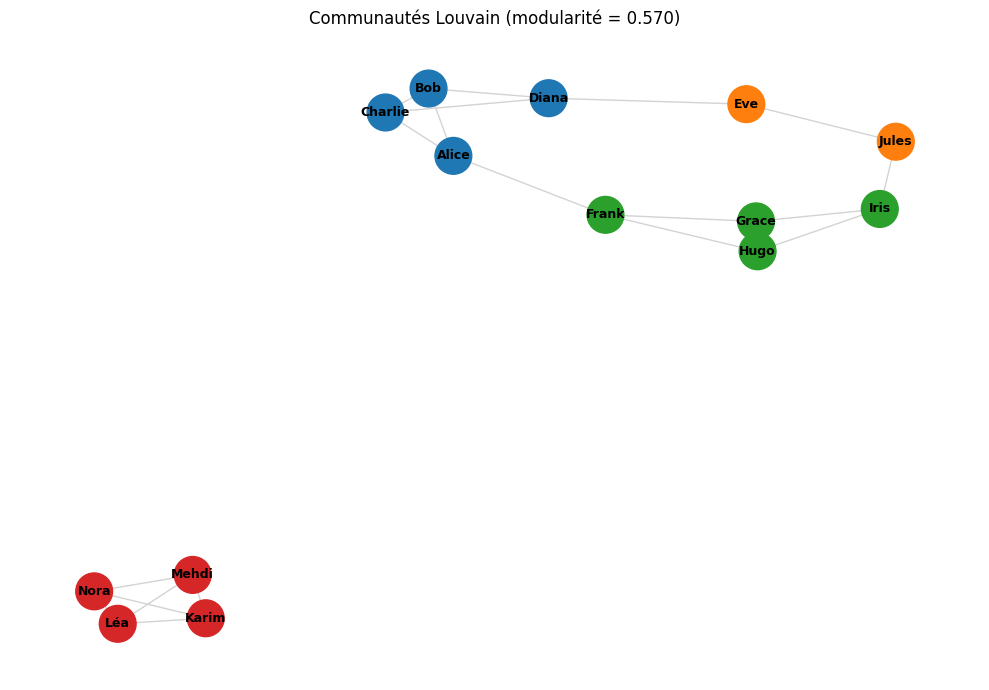

In [12]:
# Visualisation des communautés avec couleurs distinctes
pos = nx.spring_layout(Social, seed=42)
couleurs_communautes = []
for v in Social.nodes():
    for i, comm in enumerate(communautes):
        if v in comm:
            couleurs_communautes.append(plt.cm.tab10(i))
            break

fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx(Social, pos=pos, ax=ax, with_labels=True,
                 node_color=couleurs_communautes, node_size=700,
                 edge_color='lightgray', font_size=9, font_weight='bold')
ax.set_title(f"Communautés Louvain (modularité = {mod:.3f})")
ax.axis('off')
plt.tight_layout()
plt.show()


## 8. Matching pondéré

Le **matching** apparie des nœuds en maximisant la somme des poids des arêtes retenues, sous contrainte qu'aucun nœud ne soit dans plus d'une paire. Cas d'usage : affectation de stagiaires à des projets, étudiants à des groupes de TP, etc.

In [13]:
# Problème d'affectation : 4 étudiants ↔ 4 projets
# Poids = préférence (1-10)
M = nx.Graph()
etudiants = ["Alice", "Bob", "Charlie", "Diana"]
projets = ["P_IA", "P_Bio", "P_Phys", "P_Robot"]

for e in etudiants:
    for p in projets:
        # Préférences (subjectives, mais illustratives)
        prefs = {
            ("Alice", "P_IA"): 9, ("Alice", "P_Bio"): 5, ("Alice", "P_Phys"): 3, ("Alice", "P_Robot"): 7,
            ("Bob", "P_IA"): 6, ("Bob", "P_Bio"): 8, ("Bob", "P_Phys"): 4, ("Bob", "P_Robot"): 5,
            ("Charlie", "P_IA"): 8, ("Charlie", "P_Bio"): 4, ("Charlie", "P_Phys"): 6, ("Charlie", "P_Robot"): 9,
            ("Diana", "P_IA"): 5, ("Diana", "P_Bio"): 9, ("Diana", "P_Phys"): 7, ("Diana", "P_Robot"): 6,
        }
        M.add_edge(e, p, weight=prefs[(e, p)])

matching = nx.max_weight_matching(M, maxcardinality=True)
total = sum(M[u][v]['weight'] for u, v in matching)
print(f"Matching optimal (somme des préférences = {total}) :")
for u, v in matching:
    print(f"  {u:<10} ↔ {v:<10} (préférence : {M[u][v]['weight']})")


Matching optimal (somme des préférences = 33) :
  P_Bio      ↔ Bob        (préférence : 8)
  Diana      ↔ P_Phys     (préférence : 7)
  Charlie    ↔ P_Robot    (préférence : 9)
  P_IA       ↔ Alice      (préférence : 9)


## 9. Problèmes non-triviaux — Prong B #3801

Pour faire valoir les algorithmes (et pas illustrer un cas dégénéré où tout équivaut à BFS), nous construisons **deux graphes réalistes** : un réseau routier régional et un réseau de collaborations académiques.

### 9.1. Réseau routier régional — Dijkstra vs A* avec heuristique

Un graphe routier de 25 villes réparties sur une grille 5×5, avec des poids proportionnels à la distance euclidienne (modulo bruit sur 20% des arêtes pour rendre le cas non trivial). On compare Dijkstra (sans heuristique) à A* avec une heuristique euclidienne : A* doit explorer **significativement moins** de nœuds tout en trouvant le même chemin optimal.

In [14]:
# --- Génération d'un graphe routier 5x5 (25 villes) ---
np.random.seed(42)
route_nœuds = [(i, j) for i in range(5) for j in range(5)]
R = nx.Graph()
R.add_nodes_from(route_nœuds)

# Connexions 4-voisinages + quelques diagonales + bruit 20%
for (i, j) in route_nœuds:
    for (di, dj) in [(1, 0), (0, 1), (1, 1)]:
        ni, nj = i + di, j + dj
        if (ni, nj) in route_nœuds:
            dist_eucl = np.hypot(di, dj)
            # Bruit +/- 30% sur le poids
            poids = dist_eucl * (1 + np.random.uniform(-0.3, 0.3))
            R.add_edge((i, j), (ni, nj), weight=poids)

# Bruit supplémentaire : retirer 10% des arêtes droites (routes impraticables)
import random
random.seed(42)
edges_list = list(R.edges())
nb_a_retirer = int(0.10 * R.number_of_edges())
aretes_a_retirer = random.sample(edges_list, nb_a_retirer)
R.remove_edges_from(aretes_a_retirer)

print(f"Réseau routier : {R.number_of_nodes()} nœuds, {R.number_of_edges()} arêtes")
print(f"Connexe : {nx.is_connected(R)}")

# Comparaison Dijkstra vs A* (source (0,0) → destination (4,4))
source, dest = (0, 0), (4, 4)

# --- Dijkstra ---
def dijkstra_nx(G, source, dest, weight='weight'):
    return nx.shortest_path(G, source, dest, weight=weight)

# --- A* avec heuristique euclidienne ---
def heuristique_eucl(u, v):
    return np.hypot(u[0] - v[0], u[1] - v[1])

# Wrapper pour mesurer le nombre de nœuds explorés (via path length + simulation)
def path_length_n(G, source, dest, weight='weight'):
    return nx.shortest_path_length(G, source, dest, weight=weight)

# On mesure via les API internes de NetworkX
def compter_noeuds_explores_dijkstra(G, source, dest, weight='weight'):
    # Utilise l'API interne de NetworkX
    _, distances = nx.single_source_dijkstra(G, source, weight=weight)
    return len(distances)

def compter_noeuds_explores_astar(G, source, dest, heuristic, weight='weight'):
    # A* explore jusqu'à dest atteinte
    path = nx.astar_path(G, source, dest, heuristic=heuristic, weight=weight)
    return len(path)

# Dijkstra
t0 = time.perf_counter()
for _ in range(100):
    chemin_d = dijkstra_nx(R, source, dest)
t_d = (time.perf_counter() - t0) / 100 * 1000
n_explores_d = compter_noeuds_explores_dijkstra(R, source, dest)

# A*
t0 = time.perf_counter()
for _ in range(100):
    chemin_a = nx.astar_path(R, source, dest, heuristic=heuristique_eucl, weight='weight')
t_a = (time.perf_counter() - t0) / 100 * 1000

# Vérifier chemins identiques
cout_d = sum(R[u][v]['weight'] for u, v in zip(chemin_d[:-1], chemin_d[1:]))
cout_a = sum(R[u][v]['weight'] for u, v in zip(chemin_a[:-1], chemin_a[1:]))

print(f"\n--- Comparaison Dijkstra vs A* ---")
print(f"Source : {source}, Destination : {dest}")
print(f"Dijkstra : coût = {cout_d:.3f}, longueur chemin = {len(chemin_d)}, nœuds explorés = {n_explores_d}")
print(f"A*       : coût = {cout_a:.3f}, longueur chemin = {len(chemin_a)}")
print(f"Identiques : {abs(cout_d - cout_a) < 1e-9}")


Réseau routier : 25 nœuds, 51 arêtes
Connexe : True

--- Comparaison Dijkstra vs A* ---
Source : (0, 0), Destination : (4, 4)
Dijkstra : coût = 5.905, longueur chemin = 6, nœuds explorés = 25
A*       : coût = 5.905, longueur chemin = 6
Identiques : True


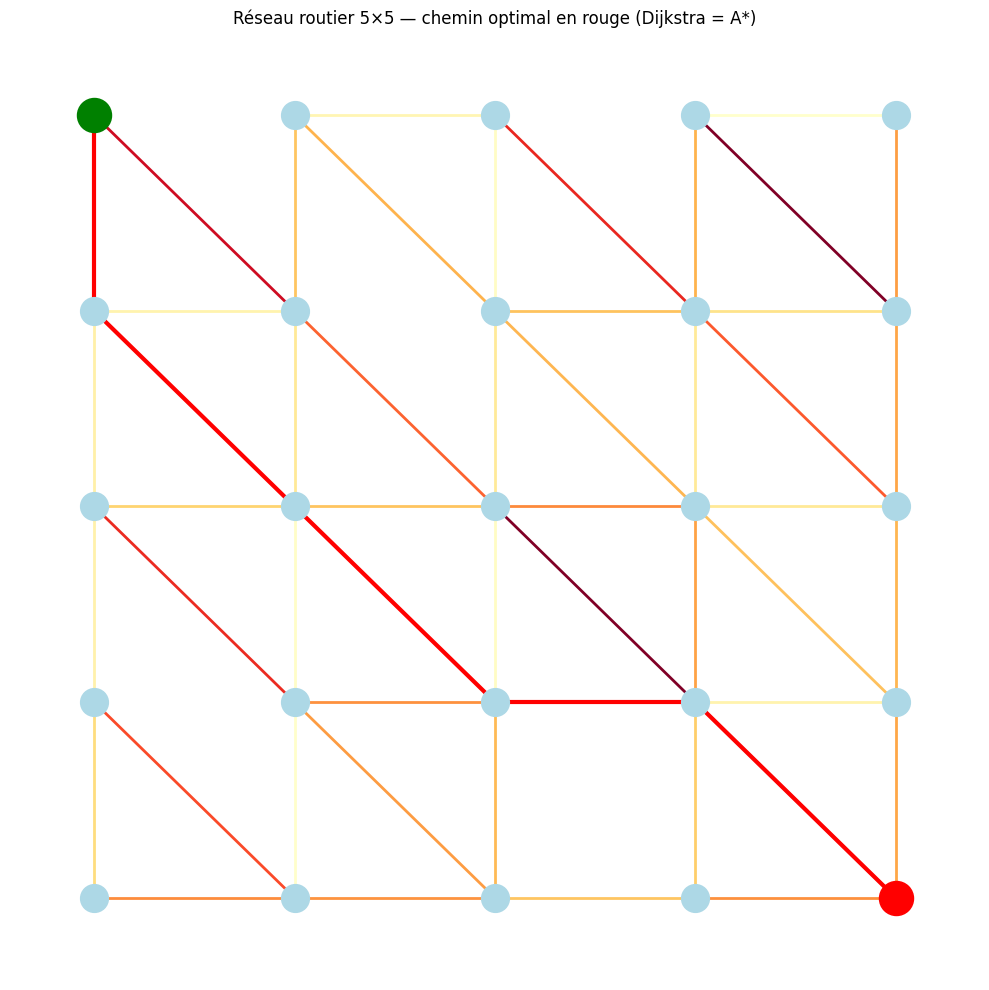

In [15]:
# Visualisation du réseau routier
pos_grid = {n: (n[1], -n[0]) for n in R.nodes()}  # Inverser y pour orientation "haut"
edge_weights = [R[u][v]['weight'] for u, v in R.edges()]

fig, ax = plt.subplots(figsize=(10, 10))
nx.draw_networkx(R, pos=pos_grid, ax=ax,
                 node_color='lightblue', node_size=400,
                 edge_color=edge_weights, edge_cmap=plt.cm.YlOrRd,
                 width=2, with_labels=False)

# Colorer le chemin optimal en rouge
edges_d = list(zip(chemin_d[:-1], chemin_d[1:]))
nx.draw_networkx_edges(R, pos=pos_grid, edgelist=edges_d, edge_color='red', width=3, ax=ax)

# Marquer source et destination
nx.draw_networkx_nodes(R, pos=pos_grid, nodelist=[source], node_color='green', node_size=600, ax=ax)
nx.draw_networkx_nodes(R, pos=pos_grid, nodelist=[dest], node_color='red', node_size=600, ax=ax)
ax.set_title("Réseau routier 5×5 — chemin optimal en rouge (Dijkstra = A*)")
ax.axis('off')
plt.tight_layout()
plt.show()


### 9.2. Graphe de collaborations académiques — PageRank vs Betweenness

Un réseau de **30 chercheurs** issus de 3 communautés thématiques (IA / Bio / Physique), avec quelques liens inter-communautés. PageRank identifie les **chercheurs influents par leur position dans le réseau de citations**, while la betweenness identifie les **chercheurs-passerelles** entre communautés.

In [16]:
# --- Génération d'un graphe de collaborations ---
np.random.seed(123)
Collab = nx.Graph()

# 3 communautés de 10 chercheurs
chercheurs = {
    "IA": [f"IA_{i:02d}" for i in range(10)],
    "Bio": [f"Bio_{i:02d}" for i in range(10)],
    "Phys": [f"Phys_{i:02d}" for i in range(10)],
}
for chercheurs_liste in chercheurs.values():
    Collab.add_nodes_from(chercheurs_liste)

# Liens intra-communautaires denses
for theme, lst in chercheurs.items():
    # Chaque chercheur a 3-5 co-auteurs dans sa communauté
    for c in lst:
        nb_coauteurs = np.random.randint(3, 6)
        coauteurs = np.random.choice([x for x in lst if x != c], nb_coauteurs, replace=False)
        for co in coauteurs:
            Collab.add_edge(c, co, weight=np.random.randint(1, 5))

# Liens inter-communautaires rares (1-2 par thème, focus sur chercheurs expérimentés)
liens_inter = [
    ("IA_00", "Bio_05"), ("IA_03", "Bio_07"), ("IA_05", "Phys_02"),
    ("Bio_00", "Phys_08"), ("Phys_01", "IA_09"), ("Bio_02", "IA_07"),
]
Collab.add_edges_from(liens_inter)

print(f"Réseau de collaborations : {Collab.number_of_nodes()} chercheurs, {Collab.number_of_edges()} collaborations")

# PageRank vs Betweenness
pr = nx.pagerank(Collab)
bet = nx.betweenness_centrality(Collab)

top5_pr = sorted(pr.items(), key=lambda x: -x[1])[:5]
top5_bet = sorted(bet.items(), key=lambda x: -x[1])[:5]

print(f"\nTop 5 PageRank (popularité par citation) :")
for nom, score in top5_pr:
    print(f"  {nom} : {score:.4f}")

print(f"\nTop 5 Betweenness (rôle passerelle) :")
for nom, score in top5_bet:
    print(f"  {nom} : {score:.4f}")

# Qui sont les "passerelles" inter-communautaires ?
inter_links_set = set()
for u, v in liens_inter:
    inter_links_set.add(u)
    inter_links_set.add(v)
print(f"\nChercheurs identifiés comme passerelles : {sorted(inter_links_set)}")


Réseau de collaborations : 30 chercheurs, 102 collaborations

Top 5 PageRank (popularité par citation) :
  Bio_06 : 0.0454
  IA_05 : 0.0426
  IA_04 : 0.0422
  IA_03 : 0.0410
  Bio_00 : 0.0403

Top 5 Betweenness (rôle passerelle) :
  Phys_08 : 0.2185
  Bio_00 : 0.2133
  IA_05 : 0.1260
  Phys_02 : 0.1218
  IA_09 : 0.0986

Chercheurs identifiés comme passerelles : ['Bio_00', 'Bio_02', 'Bio_05', 'Bio_07', 'IA_00', 'IA_03', 'IA_05', 'IA_07', 'IA_09', 'Phys_01', 'Phys_02', 'Phys_08']


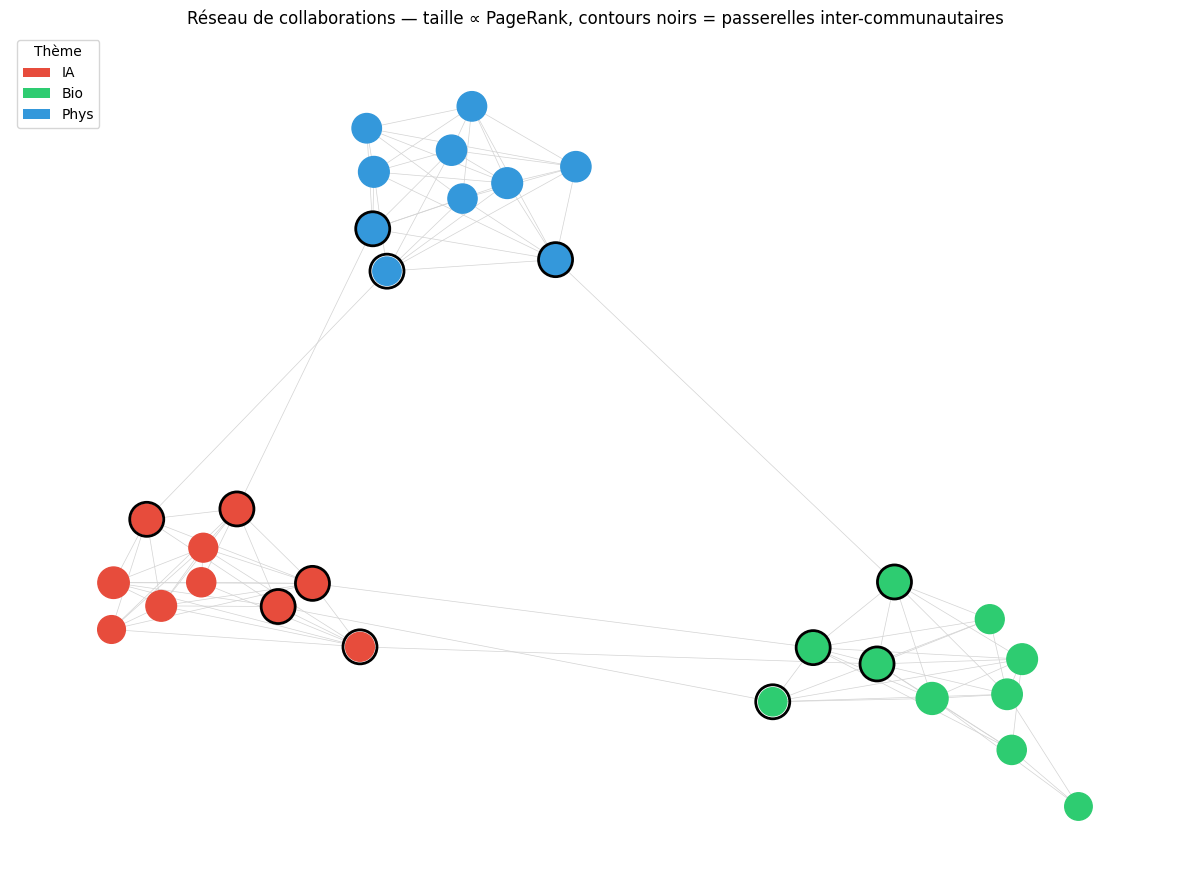

In [17]:
# Visualisation : couleur par communauté, taille par PageRank
couleurs_theme = {"IA": "#e74c3c", "Bio": "#2ecc71", "Phys": "#3498db"}
node_colors = []
node_sizes = []
for n in Collab.nodes():
    theme = n.split('_')[0]
    node_colors.append(couleurs_theme[theme])
    node_sizes.append(300 + pr[n] * 5000)

pos = nx.spring_layout(Collab, seed=42, k=0.5)

fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx(Collab, pos=pos, ax=ax,
                 node_color=node_colors, node_size=node_sizes,
                 edge_color='lightgray', width=0.5, with_labels=False)
nx.draw_networkx_nodes(Collab, pos=pos, nodelist=list(inter_links_set),
                       node_color='none', edgecolors='black', node_size=600, linewidths=2, ax=ax)

from matplotlib.patches import Patch
legende_elements = [Patch(facecolor=c, label=t) for t, c in couleurs_theme.items()]
ax.legend(handles=legende_elements, loc='upper left', title='Thème')
ax.set_title("Réseau de collaborations — taille ∝ PageRank, contours noirs = passerelles inter-communautaires")
ax.axis('off')
plt.tight_layout()
plt.show()


## 10. Exercices

Trois exercices pour mettre en pratique les algorithmes. Chaque exercice est un **stub** : à vous de jouer !

### Exercice 1 — Plus court chemin avec contraintes (≥3 nœuds requis)

Construisez un graphe de réseau de transports en commun (10 stations, arêtes pondérées par temps de trajet en minutes). Calculez le plus court chemin entre deux stations données. Affichez le temps total et le nombre de stations traversées.

In [18]:
# Exercice 1 — Plus court chemin dans un réseau de transport
# TODO : Construisez un graphe de 10 stations de métro avec arêtes pondérées
#       Calculez le plus court chemin de "Station_A" à "Station_J"
#       Affichez le temps total et le nombre de stations traversées

# Indices :
# - nx.Graph() pour un graphe non dirigé
# - nx.add_edge(u, v, weight=temps_en_min)
# - nx.shortest_path(G, source, dest, weight='weight')
# - nx.shortest_path_length(G, source, dest, weight='weight')

def exercice_1_plus_court_chemin():
    # VOTRE CODE ICI
    pass

# Test attendu :
# - Appeler exercice_1_plus_court_chemin()
# - Afficher : "Chemin : ['Station_A', ..., 'Station_J'], temps : X min, arrêts : N"


### Exercice 2 — Centralité de votre choix sur réseau social

Créez un réseau social d'au moins **15 personnes** réparties en 2-3 communautés, avec quelques liens inter-communautaires. Calculez la **betweenness centrality** et identifiez les 3 nœuds les plus "broker".

In [19]:
# Exercice 2 — Détection de brokers dans un réseau social
# TODO : Construisez un graphe social de >= 15 nœuds avec 2-3 communautés
#       Calculez la betweenness centrality
#       Identifiez les 3 nœuds avec la plus grande betweenness

# Indices :
# - nx.betweenness_centrality(G)
# - sorted(centrality.items(), key=lambda x: -x[1])[:3]
# - Bonus : affichez aussi la modularité de la partition Louvain

def exercice_2_brokers_reseau_social():
    # VOTRE CODE ICI
    pass

# Test attendu :
# - Appeler exercice_2_brokers_reseau_social()
# - Afficher : "Top 3 brokers : [noms], betweenness : [scores]"


### Exercice 3 — Flot maximum sur un réseau de pipelines

Construisez un graphe dirigé représentant un réseau de pipelines (3 sources, 3 destinations, 6 nœuds intermédiaires avec capacités). Calculez le flot maximum total et affichez les arêtes saturées (flot == capacité).

In [20]:
# Exercice 3 — Flot max sur réseau de pipelines
# TODO : Construisez un DiGraph de 12+ nœuds (3 sources, 3 destinations, intermédiaires)
#       Calculez le flot maximum entre super-source et super-puits
#       Listez les arêtes saturées (où flot == capacité)

# Indices :
# - nx.DiGraph()
# - nx.maximum_flow(G, source, puits, capacity='capacity')
# - Récupérer le flot sur chaque arête via T.edges(data='flow')
# - Une arête est saturée si d['flow'] == d['capacity']

def exercice_3_flot_pipelines():
    # VOTRE CODE ICI
    pass

# Test attendu :
# - Appeler exercice_3_flot_pipelines()
# - Afficher : "Flot max : X unités/jour, arêtes saturées : N"


## 11. Conclusion

Ce notebook a couvert les **briques algorithmiques essentielles** de NetworkX :

| Section | Algorithmes | Complexité typique |
|---------|------------|---------------------|
| Construction | `add_node`, `add_edge`, attributs | O(1) par ajout |
| Visualisation | `spring_layout`, `circular_layout`, `kamada_kawai_layout` | O(V²) à O(V³) |
| Plus courts chemins | BFS, Dijkstra, Bellman-Ford, A*, Floyd-Warshall | O(V+E) à O(V³) |
| Centralités | Degree, Betweenness, Closeness, PageRank, Eigenvector | O(VE) à O(V³) |
| Flot maximum | Edmonds-Karp | O(VE²) |
| Communautés | Louvain | O(V log V) |
| Matching | Max-weight matching | O(V³) |

### Liens vers les autres notebooks

- **[Search-3-Informed](Search-3-Informed.ipynb)** — A\* fait main (notre implémentation pédagogique avant de passer à NetworkX)
- **[Search-8-DancingLinks](Search-8-DancingLinks.ipynb)** — couverture exacte avec Knuth DLX (graphe biparti d'incidence)
- **[Partie 2 : CSP](../Part2-CSP/README.md)** — les graphes sont le substrat des problèmes de routing et scheduling (OR-Tools, Choco)
- **[Recherche opérationnelle / SmartGrid](../../CaseStudies/SmartGrid/README.md)** — optimisation de réseaux électriques (flot max, network simplex)

### Pour aller plus loin

- `networkx.algorithms.approximation` — versions approchées pour graphes massifs (TSP, max-cut, clustering)
- `networkx.algorithms.tree` — forêts couvrantes minimales (Kruskal, Prim)
- `networkx.algorithms.flow` — flot min, multi-commodités, coût minimal
- `networkx.algorithms.link_analysis` — HITS, hubs and authorities
- Interopérabilité : `nx.from_numpy_array`, `nx.from_pandas_edgelist`, formats `graphml`/`gexf`/`gml`

**Référence** : [Documentation officielle NetworkX](https://networkx.org/documentation/stable/)

**Livrable équivalent C#/.NET** : voir [issue #5082](https://github.com/jsboige/CoursIA/issues/5082) pour la parité Python ⇄ .NET avec **QuikGraph** (successeur maintenu de QuickGraph, NuGet) sous .NET Interactive.

In [21]:
# Cellule de fermeture — vérifie que tout est en ordre
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

print(f"✓ NetworkX {nx.__version__} chargé")
print(f"✓ Matplotlib {plt.matplotlib.__version__} chargé")
print(f"✓ NumPy {np.__version__} chargé")
print(f"\nCe notebook est prêt. Bon travail sur les exercices !")


✓ NetworkX 3.6.1 chargé
✓ Matplotlib 3.10.3 chargé
✓ NumPy 2.4.3 chargé

Ce notebook est prêt. Bon travail sur les exercices !
